In [3]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [1]:
from itertools import product
from sklearn.model_selection import TimeSeriesSplit

PARAM_GRID = {
    "hidden_dim": [16, 32, 64],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4, 1e-5],
    "batch_size": [8, 16],
}
N_SPLITS = 3

In [4]:
import os
DATA_PATH = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURE_COLUMNS = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGET_COLUMNS = ["CPI", "EXR"]
BREAKS = ["2008-06-01", "2016-10-01", "2022-03-01"]
WINDOWS = {
    "window_1": (None, BREAKS[0]),
    "window_2": (BREAKS[0], BREAKS[1]),
    "window_3": (BREAKS[1], BREAKS[2]),
    "window_4": (BREAKS[2], None),
    "full_sample": (None, None),
}
N_LAGS = 6  # kept short uniformly across windows; window_4 has only ~37 rows post-lag
VAL_FRAC = 0.10
TEST_FRAC = 0.10
MIN_HOLDOUT = 4
HIDDEN_DIM = 32
BATCH_SIZE = 16
EPOCHS = 500
PATIENCE = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE")


def slice_window(df: pd.DataFrame, start: str | None, end: str | None) -> pd.DataFrame:
    """Slice rows on [start, end) of a DatetimeIndex; None marks an unbounded side."""
    mask = pd.Series(True, index=df.index)
    if start is not None:
        mask &= df.index >= start
    if end is not None:
        mask &= df.index < end
    return df[mask]


def make_supervised(
    df: pd.DataFrame, feature_cols: list[str], target_cols: list[str], n_lags: int
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Convert a multivariate series into lagged inputs (X) and next-step targets (y)."""
    lagged = pd.concat(
        {f"{c}_lag{lag}": df[c].shift(lag) for c in feature_cols for lag in range(1, n_lags + 1)},
        axis=1,
    )
    data = pd.concat([lagged, df[target_cols]], axis=1).dropna()
    return data[lagged.columns], data[target_cols]


def holdout_size(n: int, frac: float, min_size: int) -> int:
    """Proportional held-out size with a practical floor for short windows."""
    return max(round(n * frac), min_size)


def chronological_split(
    X: pd.DataFrame, y: pd.DataFrame, val_size: int, test_size: int
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split time-ordered data into train/val/test without shuffling."""
    train_end, val_end = -(val_size + test_size), -test_size
    return (
        X.iloc[:train_end], X.iloc[train_end:val_end], X.iloc[val_end:],
        y.iloc[:train_end], y.iloc[train_end:val_end], y.iloc[val_end:],
    )


def to_tensor(arr: np.ndarray) -> torch.Tensor:
    """Convert a numpy array to a float32 tensor on the active device."""
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)

In [6]:
class FFNN(nn.Module):
    """Single hidden-layer feed-forward network for multivariate forecasting."""

    def __init__(self, n_in: int, n_out: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_out),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [8]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    X_val: torch.Tensor,
    y_val: torch.Tensor,
    epochs: int,
    lr: float,
    weight_decay: float,
    patience: int,
) -> dict[str, list[float]]:
    """Train with Adam/MSE and early stopping on validation loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}
    best_val_loss, best_state, wait = float("inf"), None, 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(train_loader.dataset)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(epoch_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return history

In [9]:
def rolling_window_validation(X: pd.DataFrame, y: pd.DataFrame, params: dict, n_splits: int) -> float:
    """Walk-forward validation: fit on each expanding fold, score MSE on the following block."""
    tscv = TimeSeriesSplit(n_splits=min(n_splits, len(X) - 1))
    scores = []
    for train_idx, val_idx in tscv.split(X):
        scaler_X, scaler_y = StandardScaler(), StandardScaler()
        X_tr = scaler_X.fit_transform(X.iloc[train_idx])
        X_va = scaler_X.transform(X.iloc[val_idx])
        y_tr = scaler_y.fit_transform(y.iloc[train_idx])
        y_va = scaler_y.transform(y.iloc[val_idx])

        loader = DataLoader(TensorDataset(to_tensor(X_tr), to_tensor(y_tr)), batch_size=params["batch_size"], shuffle=True)
        model = FFNN(X_tr.shape[1], y_tr.shape[1], params["hidden_dim"]).to(DEVICE)
        train_model(model, loader, to_tensor(X_va), to_tensor(y_va), EPOCHS, params["lr"], params["weight_decay"], PATIENCE)
        scores.append(nn.MSELoss()(model(to_tensor(X_va)), to_tensor(y_va)).item())
    return float(np.mean(scores))


def grid_search(X: pd.DataFrame, y: pd.DataFrame, grid: dict, n_splits: int) -> tuple[dict, float]:
    """Exhaustively score every hyperparameter combination via rolling-window validation."""
    keys = list(grid.keys())
    best_score, best_params = float("inf"), None
    for combo in product(*grid.values()):
        params = dict(zip(keys, combo))
        score = rolling_window_validation(X, y, params, n_splits)
        if score < best_score:
            best_score, best_params = score, params
    return best_params, best_score

In [10]:
def forecast(model: nn.Module, X: torch.Tensor, scaler_y: StandardScaler) -> np.ndarray:
    """Generate inverse-scaled predictions for a feature tensor."""
    model.eval()
    with torch.no_grad():
        pred = model(X).cpu().numpy()
    return scaler_y.inverse_transform(pred)


def report_metrics(actual: pd.DataFrame, pred: np.ndarray, cols: list[str]) -> pd.DataFrame:
    """Compute RMSE and MAE per series."""
    rows = [
        {
            "series": c,
            "rmse": mean_squared_error(actual[c], pred[:, i]) ** 0.5,
            "mae": mean_absolute_error(actual[c], pred[:, i]),
        }
        for i, c in enumerate(cols)
    ]
    return pd.DataFrame(rows).set_index("series")

In [11]:
def run_window(df: pd.DataFrame, start: str | None, end: str | None) -> dict:
    """Tune, fit, and evaluate an FFNN on a single structural-break window."""
    window_df = slice_window(df, start, end)
    X, y = make_supervised(window_df, FEATURE_COLUMNS, TARGET_COLUMNS, N_LAGS)

    n = len(X)
    test_size = holdout_size(n, TEST_FRAC, MIN_HOLDOUT)
    val_size = holdout_size(n, VAL_FRAC, MIN_HOLDOUT)
    X_train, X_val, X_test, y_train, y_val, y_test = chronological_split(X, y, val_size, test_size)

    best_params, _ = grid_search(X_train, y_train, PARAM_GRID, N_SPLITS)

    scaler_X, scaler_y = StandardScaler(), StandardScaler()
    X_train_s = scaler_X.fit_transform(X_train)
    X_val_s = scaler_X.transform(X_val)
    X_test_s = scaler_X.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train)
    y_val_s = scaler_y.transform(y_val)

    train_loader = DataLoader(
        TensorDataset(to_tensor(X_train_s), to_tensor(y_train_s)), batch_size=best_params["batch_size"], shuffle=True
    )

    model = FFNN(X_train_s.shape[1], y_train_s.shape[1], best_params["hidden_dim"]).to(DEVICE)
    history = train_model(
        model, train_loader, to_tensor(X_val_s), to_tensor(y_val_s), EPOCHS,
        best_params["lr"], best_params["weight_decay"], PATIENCE
    )

    pred_test = forecast(model, to_tensor(X_test_s), scaler_y)
    metrics = report_metrics(y_test, pred_test, TARGET_COLUMNS)

    return {
        "model": model, "history": history, "metrics": metrics,
        "y_test": y_test, "pred_test": pred_test, "best_params": best_params,
        "date_range": (window_df.index[0], window_df.index[-1]),
        "n_train": len(X_train), "n_val": len(X_val), "n_test": len(X_test),
    }

In [12]:
def plot_history(history: dict[str, list[float]], title: str) -> None:
    """Plot training and validation loss curves for a window."""
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
def plot_forecasts(actual: pd.DataFrame, pred: np.ndarray, cols: list[str], title: str) -> None:
    """Plot actual vs predicted values for each target series in a window's test split."""
    fig, axes = plt.subplots(len(cols), 1, figsize=(8, 3 * len(cols)), sharex=True)
    for i, (ax, c) in enumerate(zip(axes, cols)):
        ax.plot(actual.index, actual[c], label="actual")
        ax.plot(actual.index, pred[:, i], label="predicted")
        ax.set_title(f"{title} - {c}")
        ax.legend()
    plt.tight_layout()
    plt.show()

window_1: 2003-01-01 to 2008-05-01  train=47 val=6 test=6
            rmse       mae
series                    
CPI     5.630934  5.180322
EXR     5.153435  5.085406

window_2: 2008-06-01 to 2016-09-01  train=76 val=9 test=9
            rmse       mae
series                    
CPI     7.190206  6.863427
EXR     8.197001  8.172033

window_3: 2016-10-01 to 2022-02-01  train=47 val=6 test=6
             rmse        mae
series                      
CPI     16.872965  14.807383
EXR      9.421829   8.878331

window_4: 2022-03-01 to 2025-10-01  train=30 val=4 test=4
            rmse       mae
series                    
CPI     3.042094  2.965060
EXR     8.044495  7.538019

full_sample: 2003-01-01 to 2025-10-01  train=214 val=27 test=27
             rmse        mae
series                      
CPI     48.394553  47.539791
EXR     10.185255   9.639071

                         rmse        mae
window      series                      
window_1    CPI      5.630934   5.180322
            EXR     

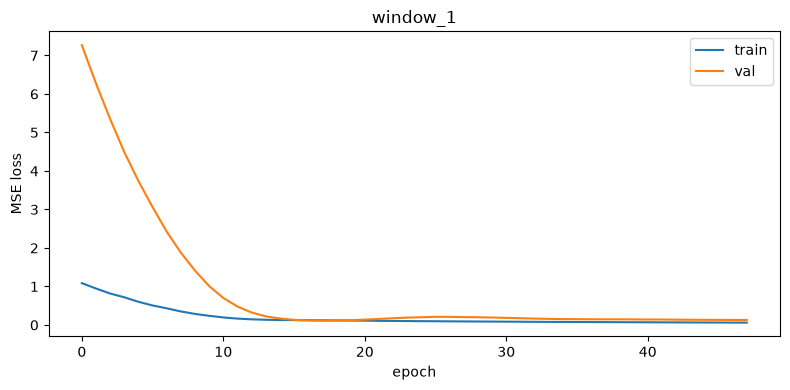

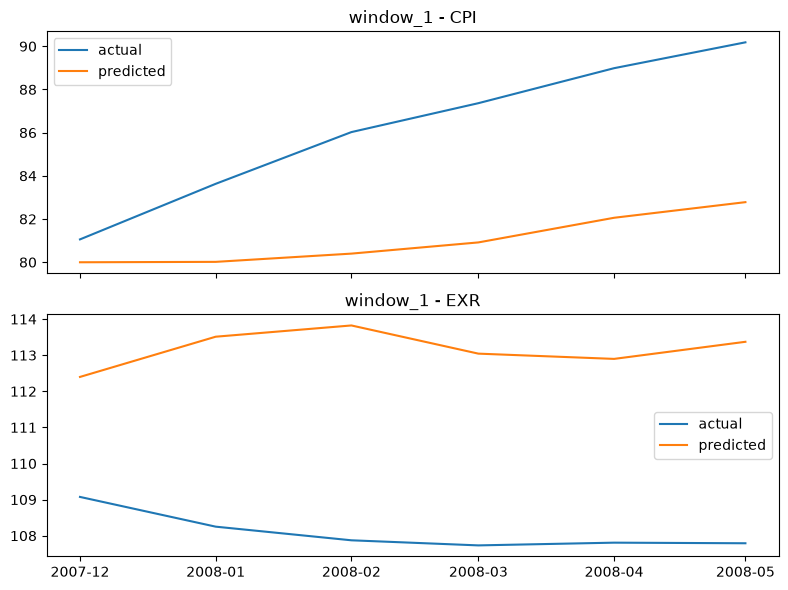

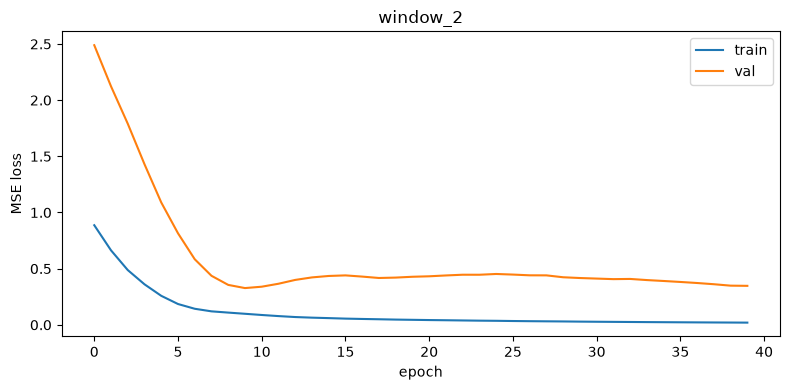

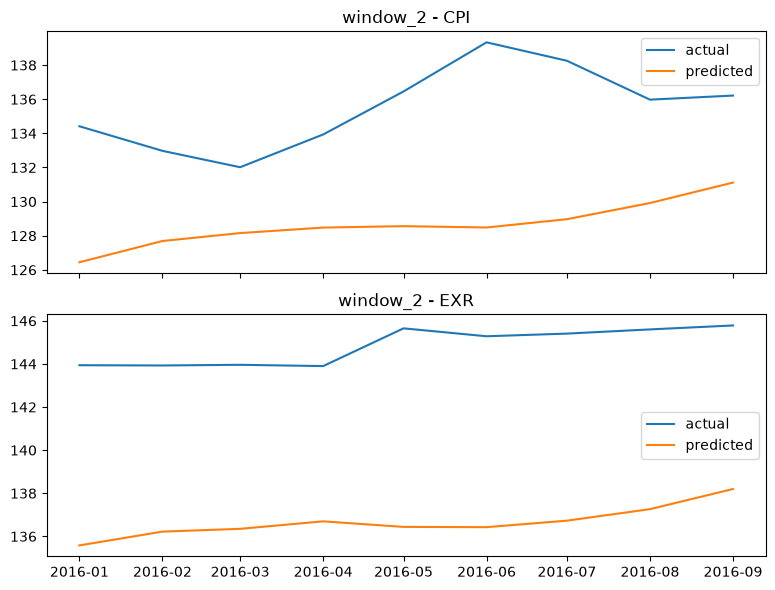

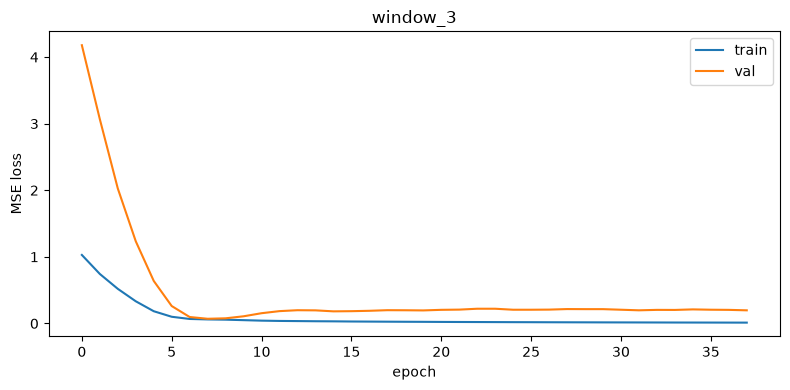

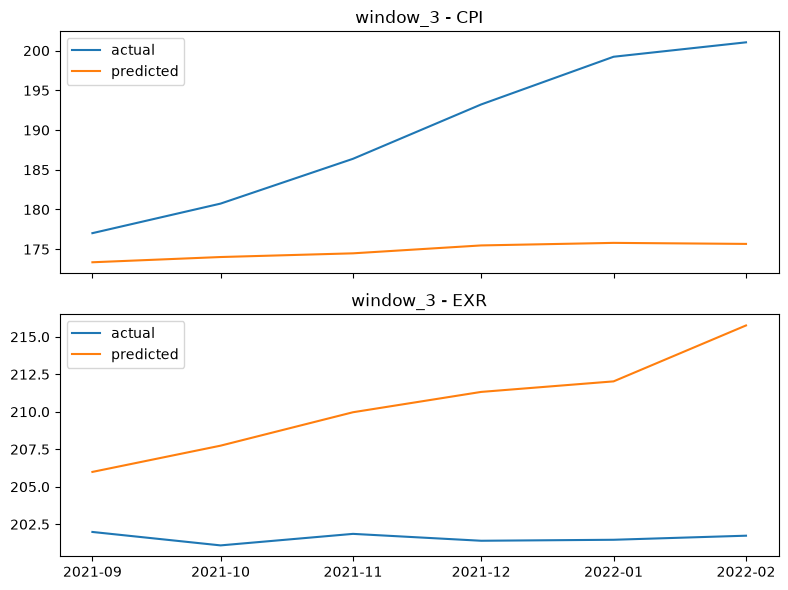

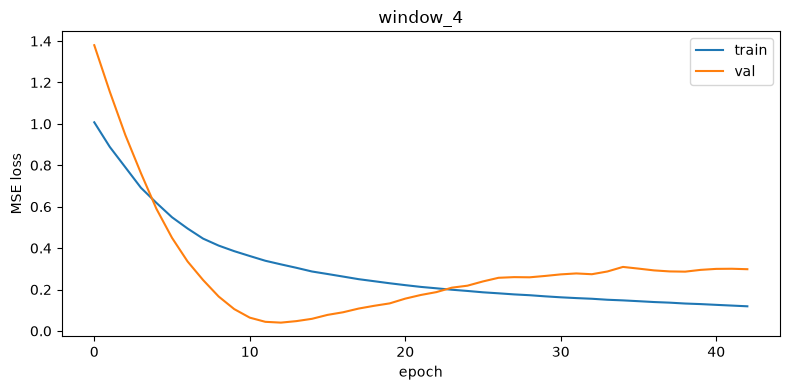

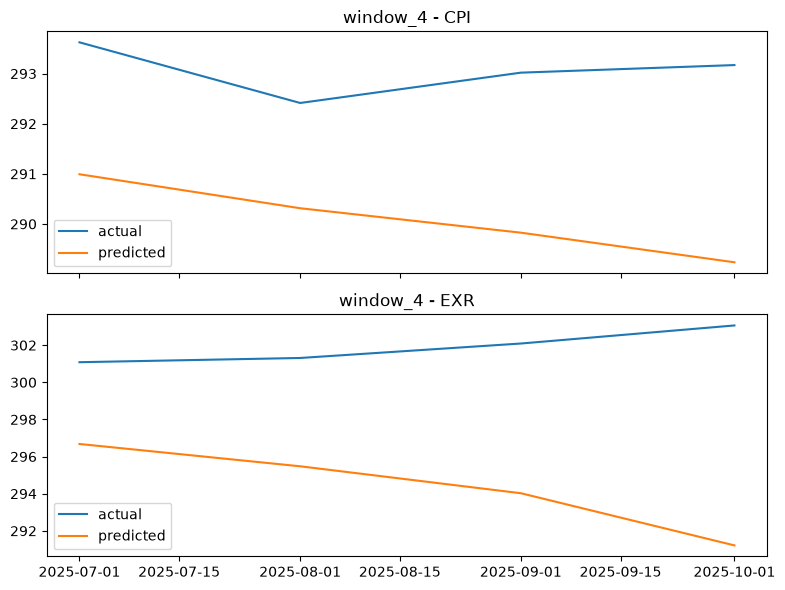

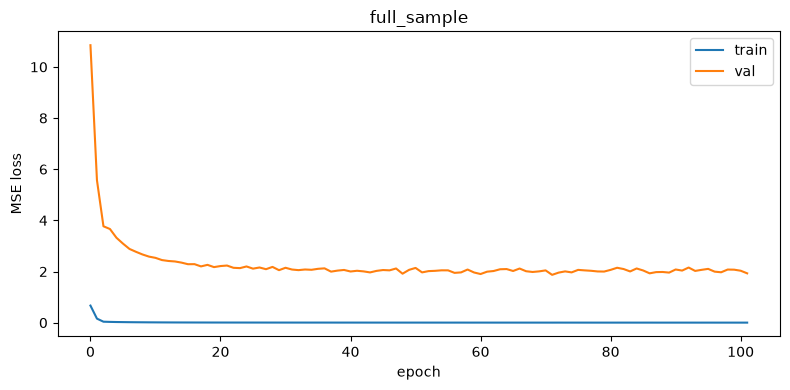

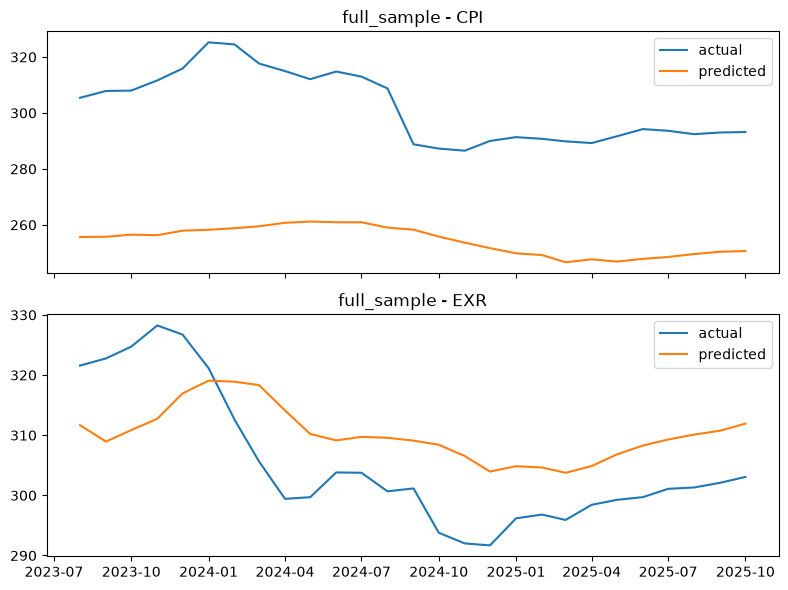

In [14]:
df = load_data(DATA_PATH)
results = {}
for name, (start, end) in WINDOWS.items():
    results[name] = run_window(df, start, end)

for name, r in results.items():
    d0, d1 = r["date_range"]
    print(f"{name}: {d0.date()} to {d1.date()}  train={r['n_train']} val={r['n_val']} test={r['n_test']}")
    print(r["metrics"])
    print()

summary = pd.concat({name: r["metrics"] for name, r in results.items()}, names=["window", "series"])
print(summary)

# %%
for name, r in results.items():
    plot_history(r["history"], name)
    plot_forecasts(r["y_test"], r["pred_test"], TARGET_COLUMNS, name)

In [15]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
canon_map = {"window_1": "W1", "window_2": "W2", "window_3": "W3", "window_4": "W4", "full_sample": "W5"}
export_rows = [
    {"window": canon_map[name], "target": series, "RMSE": row["rmse"], "MAE": row["mae"]}
    for name, r in results.items() for series, row in r["metrics"].iterrows()
]
pd.DataFrame(export_rows).to_csv(f"../results/metrics_ffnn.csv", index=False)

In [16]:
pred_rows = [
    {"window": canon_map[name], "target": col, "date": date,
     "actual": r["y_test"].iloc[i][col], "predicted": r["pred_test"][i, j]}
    for name, r in results.items()
    for i, date in enumerate(r["y_test"].index)
    for j, col in enumerate(TARGET_COLUMNS)
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_ffnn.csv", index=False)